# Hopfield network



In [2]:
import torch
from torch import nn
from torch.nn import functional as F

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## MNIST

In [3]:
import torchvision
import torchvision.transforms as transforms

DOWNLOAD_PATH = '../datasets'

# normalize so that the mean of the data is zero and the variance is one
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) 
])

train = torchvision.datasets.MNIST(root=DOWNLOAD_PATH, train=True, download=True, transform=transform)
test_val = torchvision.datasets.MNIST(root=DOWNLOAD_PATH, train=False, download=True, transform=transform)
test, val = torch.utils.data.random_split(test_val, [0.5, 0.5])

In [71]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train, batch_size=4, shuffle=True)
# test_loader = DataLoader(test, batch_size=len(test), shuffle=True)
# val_loader = DataLoader(val, batch_size=len(val), shuffle=True)

In [76]:
batch_x, batch_y = next(iter(train_loader))

batch_x.shape, batch_y

(torch.Size([4, 1, 28, 28]), tensor([3, 5, 5, 0]))

In [77]:
v = batch_x.reshape(4, -1, 1)

W = (v @ v.transpose(-1, -2)).mean(0)

W.shape

torch.Size([784, 784])

In [88]:
W[0]

tensor([ 1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,
         1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,
         1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,
         1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,
         1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,
         1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,
         1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,
         1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,
         1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,
         1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,
         1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,
         1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,
         1.0000,  1.0000,  1.0000,  1.00

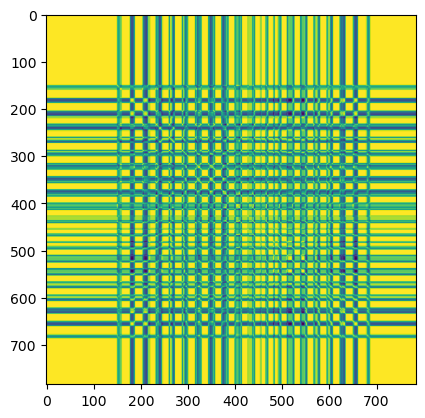

In [78]:
plt.imshow(W)

In [89]:
preact = W @ batch_x.reshape(-1, 4)
x_recon = torch.where(preact > 0, torch.ones_like(preact), -torch.ones_like(preact))

x_recon.shape

torch.Size([784, 4])

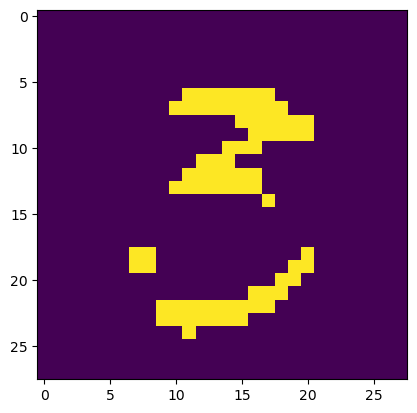

In [93]:
plt.imshow(x_recon[:, 0].reshape(28, 28))